# Mental health ML (tabular)

This notebook is the main ML workflow (data → train → save model).

1. Edit **`config.yaml`** (`data_path`, `target_column`, optional `drop_columns`).
2. **Run all cells** to (optionally) build a demo CSV, train, and write **`artifacts/model_bundle.joblib`**.
3. For the web app, start the API: `python -m uvicorn mental_health_ml.serve:app --host 127.0.0.1 --port 8000`

Kaggle dataset: [Mental Health](https://www.kaggle.com/datasets/imtkaggleteam/mental-health)

In [56]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

ROOT = Path.cwd().resolve()
if not (ROOT / "config.yaml").is_file() and (ROOT / "ml" / "config.yaml").is_file():
    ROOT = ROOT / "ml"

DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"
CONFIG_PATH = ROOT / "config.yaml"

FEATURE_SCHEMA: dict[str, list[str]] = {
    "Gender": ["Female", "Male", "Other"],
    "Country": ["Canada", "India", "Nepal", "UK", "US"],
    "family_history": ["No", "Yes"],
    "work_interference": ["Never", "Often", "Rarely", "Sometimes"],
    "remote_work": ["No", "Yes"],
}
NUMERIC_FEATURES = ["Age"]
TARGET_COLUMN = "treatment"
TARGET_LABELS = ["No", "Yes"]

In [57]:
def load_config() -> dict[str, Any]:
    if not CONFIG_PATH.is_file():
        raise FileNotFoundError(f"Missing {CONFIG_PATH}. Copy config.example.yaml to config.yaml.")
    with CONFIG_PATH.open(encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_csv(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(
            f"Data file not found: {path}. Put your CSV under data/ and set data_path in config.yaml."
        )
    return pd.read_csv(path)


def load_dataframe_from_config(cfg: dict[str, Any]) -> pd.DataFrame:
    source = str(cfg.get("dataset_source", "local")).lower()
    if source == "kaggle":
        import kagglehub
        from kagglehub import KaggleDatasetAdapter

        dataset = str(cfg.get("kaggle_dataset") or "imtkaggleteam/mental-health")
        file_path = str(cfg.get("kaggle_file_path") or "")

        if not file_path:
            base = Path(kagglehub.dataset_download(dataset))
            csvs = sorted([p for p in base.rglob("*.csv") if p.is_file()])
            if not csvs:
                raise ValueError(f"No CSV files found in Kaggle dataset: {dataset}")
            file_path = csvs[0].name

        return kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            dataset,
            file_path,
        )

    data_path = ROOT / str(cfg["data_path"])
    return load_csv(data_path)


def yn(value: Any) -> str | None:
    s = str(value).strip().lower()
    if s in {"yes", "y", "true", "1", "present", "positive"}:
        return "yes"
    if s in {"no", "n", "false", "0", "none", "negative"}:
        return "no"
    return None


def derive_mental_state(df: pd.DataFrame) -> pd.Series:
    lowered = {c: c.strip().lower().replace(" ", "_") for c in df.columns}
    dep_cols = [c for c, lc in lowered.items() if "depress" in lc or "sad" in lc]
    anx_cols = [c for c, lc in lowered.items() if "anx" in lc or "panic" in lc or "worry" in lc]
    proxy_cols = [
        c
        for c, lc in lowered.items()
        if any(k in lc for k in ["mental", "treatment", "interference", "stress", "family_history"])
    ]

    out: list[str] = []
    for _, row in df.iterrows():
        dep_yes = any(yn(row[c]) == "yes" for c in dep_cols)
        anx_yes = any(yn(row[c]) == "yes" for c in anx_cols)

        if dep_yes:
            out.append("depression")
            continue
        if anx_yes:
            out.append("anxiety")
            continue

        yes_votes = 0
        no_votes = 0
        for c in proxy_cols:
            v = yn(row[c])
            if v == "yes":
                yes_votes += 1
            elif v == "no":
                no_votes += 1

        if no_votes >= 2 and yes_votes == 0:
            out.append("fluke_or_low_risk")
        else:
            out.append("other")

    return pd.Series(out, index=df.index, name="mental_state")


def prepare_xy(
    df: pd.DataFrame,
    target_mode: str,
    target_column: str,
    drop_columns: list[str] | None,
) -> tuple[pd.DataFrame, pd.Series, str]:
    drops = [c for c in (drop_columns or []) if c in df.columns]

    if target_mode == "derived_mental_state":
        y = derive_mental_state(df)
        used_target = "mental_state"

        leak_prone = []
        for c in df.columns:
            lc = c.strip().lower().replace(" ", "_")
            if any(k in lc for k in ["treatment", "depress", "anx", "panic", "worry", "mental_state"]):
                leak_prone.append(c)

        X = df.drop(columns=drops + leak_prone, errors="ignore").copy()
    else:
        if target_column not in df.columns:
            raise ValueError(f"target_column '{target_column}' not in columns: {list(df.columns)}")
        y = df[target_column]
        used_target = target_column
        X = df.drop(columns=drops + [target_column], errors="ignore").copy()

    drop_noise: list[str] = []
    for col in X.columns:
        uniq = X[col].nunique(dropna=True)
        ratio = uniq / max(len(X), 1)
        if ratio > 0.75:
            drop_noise.append(col)
    X = X.drop(columns=drop_noise, errors="ignore")

    return X, y, used_target


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical = [c for c in X.columns if c not in numeric]

    transformers: list = []
    if numeric:
        transformers.append(("num", SimpleImputer(strategy="median"), numeric))
    if categorical:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("impute", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                categorical,
            )
        )

    return ColumnTransformer(transformers, remainder="drop")


def candidate_model_grids() -> dict[str, tuple[Any, dict[str, list[Any]]]]:
    return {
        "random_forest": (
            RandomForestClassifier(
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
            {
                "clf__n_estimators": [260],
                "clf__max_depth": [16, None],
                "clf__min_samples_leaf": [1, 2],
                "clf__min_samples_split": [2],
            },
        ),
        "extra_trees": (
            ExtraTreesClassifier(
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
            {
                "clf__n_estimators": [320],
                "clf__max_depth": [24, None],
                "clf__min_samples_leaf": [1, 2],
                "clf__min_samples_split": [2],
            },
        ),
    }


def fit_tuned_model(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    cv_splits: int = 3,
) -> tuple[str, Pipeline, float, dict[str, Any]]:
    prep = build_preprocessor(X_train)
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    best_name = ""
    best_score = -1.0
    best_estimator: Pipeline | None = None
    best_params: dict[str, Any] = {}

    for name, (model, grid) in candidate_model_grids().items():
        pipe = Pipeline([("prep", prep), ("clf", model)])
        search = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            cv=cv,
            scoring="f1_macro",
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)

        score = float(search.best_score_)
        print(f"{name}: tuned CV f1_macro={score:.4f} | best_params={search.best_params_}")

        if score > best_score + 1e-6:
            best_name = name
            best_score = score
            best_estimator = search.best_estimator_
            best_params = dict(search.best_params_)

    assert best_estimator is not None
    return best_name, best_estimator, best_score, best_params


def repeated_cv_stability(
    estimator: Pipeline,
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    cv_splits: int = 3,
    seeds: list[int] | None = None,
) -> dict[str, float]:
    seeds = seeds or [42, 99]
    fold_scores: list[float] = []

    for seed in seeds:
        cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)
        scores = cross_val_score(estimator, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
        fold_scores.extend([float(x) for x in scores])

    arr = np.asarray(fold_scores, dtype=float)
    return {
        "mean": float(arr.mean()),
        "std": float(arr.std(ddof=0)),
        "min": float(arr.min()),
        "max": float(arr.max()),
    }


def choose_best_model(X_train: pd.DataFrame, y_train: np.ndarray) -> tuple[str, Pipeline, float]:
    name, est, score, _params = fit_tuned_model(X_train, y_train)
    return name, est, score


def prepare_schema_xy(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    required = NUMERIC_FEATURES + list(FEATURE_SCHEMA.keys()) + [TARGET_COLUMN]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Dataset missing required columns: {missing}")

    work = df[required].copy()

    mask = pd.Series(True, index=work.index)
    for col, allowed in FEATURE_SCHEMA.items():
        mask &= work[col].astype(str).isin(allowed)
    mask &= work[TARGET_COLUMN].astype(str).isin(TARGET_LABELS)
    filtered = work[mask].copy()

    X = filtered[NUMERIC_FEATURES + list(FEATURE_SCHEMA.keys())]
    y = filtered[TARGET_COLUMN].astype(str)
    return X, y


def build_schema_preprocessor() -> ColumnTransformer:
    cat_cols = list(FEATURE_SCHEMA.keys())
    cat_categories = [FEATURE_SCHEMA[c] for c in cat_cols]

    transformers: list = []
    transformers.append(("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES))
    transformers.append(
        (
            "cat",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            categories=cat_categories,
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            cat_cols,
        )
    )
    return ColumnTransformer(transformers, remainder="drop")


def choose_best_model_schema(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
) -> tuple[str, Pipeline, float, dict[str, Any], dict[str, float]]:
    best_name, best_pipe, best_score, best_params = fit_tuned_model(X_train, y_train, cv_splits=3)
    stability = repeated_cv_stability(best_pipe, X_train, y_train, cv_splits=3, seeds=[42, 99])
    return best_name, best_pipe, best_score, best_params, stability

## Load config, train, save model

In [58]:
def load_sentiment_dataframe(cfg: dict[str, Any]) -> pd.DataFrame:
    import kagglehub

    dataset = str(cfg.get("sentiment_kaggle_dataset") or "suchintikasarkar/sentiment-analysis-for-mental-health")
    file_path = str(cfg.get("sentiment_kaggle_file_path") or "")

    base = Path(kagglehub.dataset_download(dataset))
    csvs = sorted([p for p in base.rglob("*.csv") if p.is_file()])
    if not csvs:
        raise ValueError(f"No CSV files found for sentiment dataset: {dataset}")

    if not file_path:
        candidates = [p for p in csvs if p.name.lower() == "combined data.csv"]
        file = candidates[0] if candidates else csvs[0]
    else:
        file = base / file_path
        if not file.is_file():
            matches = [p for p in csvs if p.name == file_path]
            if not matches:
                raise ValueError(f"sentiment_kaggle_file_path not found: {file_path}")
            file = matches[0]

    sdf = pd.read_csv(file)
    return sdf


def map_sentiment_status(status: Any) -> str | None:
    s = str(status).strip().lower()
    if "anx" in s:
        return "anxiety"
    if "depress" in s:
        return "depression"
    if "bipolar" in s:
        return "bipolar"
    if "schizo" in s:
        return "schizophrenia"
    if "eating" in s:
        return "eating_disorder"
    if "dysth" in s:
        return "dysthymia"
    if "stress" in s:
        return "anxiety"
    if "suicid" in s:
        return "depression"
    return None


def map_condition_to_pace_state(condition: str) -> str:
    c = str(condition).strip().lower()
    if c in {"schizophrenia", "eating_disorder"}:
        return "burnout_risk"
    if c in {"anxiety", "bipolar"}:
        return "overworked"
    if c in {"depression", "dysthymia"}:
        return "underworked"
    return "inconsistent"


def derive_sentiment_pace_states(sent_labels: pd.Series, feats: pd.DataFrame) -> pd.Series:
    out: list[str] = []
    for i, cond in enumerate(sent_labels.astype(str).tolist()):
        neg_hits = float(feats.iloc[i].get("neg_word_hits", 0.0))
        risk_hits = float(feats.iloc[i].get("risk_word_hits", 0.0))
        punct = float(feats.iloc[i].get("exclamation_count", 0.0)) + float(feats.iloc[i].get("question_count", 0.0))
        words = float(feats.iloc[i].get("word_count", 0.0))

        if risk_hits >= 1:
            out.append("burnout_risk")
            continue

        base = map_condition_to_pace_state(cond)
        if base == "underworked" and words <= 6 and neg_hits >= 1:
            out.append("underworked")
        elif base == "overworked" and (neg_hits >= 2 or punct >= 2):
            out.append("overworked")
        elif base in {"overworked", "underworked", "burnout_risk"}:
            out.append(base)
        else:
            out.append("balanced")

    return pd.Series(out, index=sent_labels.index, name="pace_state")


def text_signal_features(statements: pd.Series) -> pd.DataFrame:
    s = statements.fillna("").astype(str)
    lower = s.str.lower()

    neg_words = ["sad", "hopeless", "tired", "panic", "afraid", "anxious", "depressed", "alone"]
    risk_words = ["suicide", "die", "harm", "kill", "worthless", "empty"]

    out = pd.DataFrame(index=s.index)
    out["statement_len"] = s.str.len().astype(float)
    out["word_count"] = s.str.split().str.len().fillna(0).astype(float)
    out["exclamation_count"] = s.str.count("!").astype(float)
    out["question_count"] = s.str.count("\\?").astype(float)
    out["neg_word_hits"] = sum(lower.str.count(rf"\\b{w}\\b") for w in neg_words).astype(float)
    out["risk_word_hits"] = sum(lower.str.count(rf"\\b{w}\\b") for w in risk_words).astype(float)
    return out


def derive_aspect_labels_from_geo(df: pd.DataFrame) -> tuple[pd.Series, dict[str, list[str]]]:
    aspect_keywords = {
        "anxiety": ["anxiety disorders", "anxiety disorder", "anxiety"],
        "depression": ["depressive disorders", "major depression", "depression"],
        "dysthymia": ["dysthymia"],
        "bipolar": ["bipolar disorders", "bipolar disorder", "bipolar"],
        "schizophrenia": ["schizophrenia disorders", "schizophrenia"],
        "eating_disorder": ["eating disorders", "eating disorder"],
    }

    aspect_cols: dict[str, list[str]] = {k: [] for k in aspect_keywords}
    for col in df.columns:
        lc = str(col).lower()
        for aspect, keys in aspect_keywords.items():
            if any(k in lc for k in keys):
                aspect_cols[aspect].append(col)

    aspect_cols = {k: v for k, v in aspect_cols.items() if v}
    if len(aspect_cols) < 2:
        raise ValueError(f"Not enough aspect columns in geo data: {aspect_cols}")

    aspect_scores = pd.DataFrame(index=df.index)
    for aspect, cols in aspect_cols.items():
        aspect_scores[aspect] = df[cols].astype(float).max(axis=1)

    denom = aspect_scores.std(ddof=0).replace(0, 1)
    norm_scores = (aspect_scores - aspect_scores.mean()) / denom
    idx = norm_scores.values.argmax(axis=1)
    labels = list(norm_scores.columns)
    y = pd.Series([labels[i] for i in idx], index=df.index, name="dominant_condition")
    return y, aspect_cols


def build_hybrid_dataset(
    geo_df: pd.DataFrame,
    sent_df: pd.DataFrame,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.Series, pd.Series, dict[str, Any], dict[str, Any]]:
    rng = np.random.default_rng(random_state)

    y_geo_condition, aspect_map = derive_aspect_labels_from_geo(geo_df)
    y_geo = y_geo_condition.map(map_condition_to_pace_state).astype(str)

    geo_features = [c for c in ["Entity", "Code", "Year"] if c in geo_df.columns]
    if not geo_features:
        raise ValueError("Geo dataset missing Entity/Code/Year")

    X_geo = geo_df[geo_features].copy()
    for col in ["statement_len", "word_count", "exclamation_count", "question_count", "neg_word_hits", "risk_word_hits"]:
        X_geo[col] = 0.0

    if "statement" not in sent_df.columns or "status" not in sent_df.columns:
        raise ValueError("Sentiment dataset must contain 'statement' and 'status' columns")

    sent_labels = sent_df["status"].map(map_sentiment_status)
    sent_keep = sent_labels.notna()
    sent_df2 = sent_df[sent_keep].copy()
    y_sent_condition = sent_labels[sent_keep].astype(str)

    text_feats = text_signal_features(sent_df2["statement"])
    y_sent = derive_sentiment_pace_states(y_sent_condition, text_feats).astype(str)

    geo_by_class: dict[str, pd.DataFrame] = {}
    geo_state = y_geo.astype(str)
    for klass in sorted(geo_state.unique()):
        geo_by_class[str(klass)] = geo_df[geo_state == klass]

    assigned = []
    for klass in y_sent:
        pool = geo_by_class.get(str(klass))
        if pool is None or pool.empty:
            pool = geo_df
        row = pool.iloc[int(rng.integers(0, len(pool)))]
        assigned.append({c: row[c] for c in geo_features})

    X_sent = pd.DataFrame(assigned, index=sent_df2.index)
    for c in text_feats.columns:
        X_sent[c] = text_feats[c].values

    X_all = pd.concat([X_geo, X_sent], axis=0, ignore_index=True)
    y_all = pd.concat([y_geo.astype(str), y_sent.astype(str)], axis=0, ignore_index=True)

    input_schema = {c: ("number" if c == "Year" else "text") for c in geo_features}
    input_schema.update({
        "statement_len": "number",
        "word_count": "number",
        "exclamation_count": "number",
        "question_count": "number",
        "neg_word_hits": "number",
        "risk_word_hits": "number",
    })

    source_all = pd.Series(
        ["geography"] * len(X_geo) + ["sentiment"] * len(X_sent),
        name="source",
    )

    source_class_counts = {
        "geography": y_geo.astype(str).value_counts().to_dict(),
        "sentiment": y_sent.astype(str).value_counts().to_dict(),
    }

    meta = {
        "geo_rows": int(len(X_geo)),
        "sentiment_rows_used": int(len(X_sent)),
        "aspect_columns": aspect_map,
        "source_class_counts": source_class_counts,
        "labeling": "derived_pace_state",
        "pace_states": sorted(pd.Series(y_all).astype(str).unique().tolist()),
    }
    return X_all, y_all, source_all, input_schema, meta

In [59]:
cfg = load_config()
source = str(cfg.get("dataset_source", "local")).lower()
combine_sentiment = bool(cfg.get("combine_sentiment", True))

geo_df = load_dataframe_from_config(cfg)
if source == "local" and "sample_mental_health.csv" in str(cfg.get("data_path", "")):
    print("WARNING: You are training on demo sample data. Accuracy here is not representative.")
    print("Set config.yaml -> dataset_source: kaggle to train from Kaggle datasets.")

input_schema: dict[str, Any]
used_target: str
training_metadata: dict[str, Any] = {}

if source == "kaggle" and combine_sentiment:
    sent_df = load_sentiment_dataframe(cfg)
    sentiment_max_rows = int(cfg.get("sentiment_max_rows", 20000))
    if len(sent_df) > sentiment_max_rows:
        sent_df = sent_df.sample(n=sentiment_max_rows, random_state=int(cfg.get("random_state", 42)))

    X, y, source_labels, input_schema, hybrid_meta = build_hybrid_dataset(
        geo_df,
        sent_df,
        random_state=int(cfg.get("random_state", 42)),
    )
    used_target = "pace_state"
    training_metadata = {
        "dataset_source": "kaggle_hybrid",
        "model_goal": "pace_balance_classification",
        **hybrid_meta,
    }
    print("Using hybrid dataset (geography + sentiment) for Pace state modeling.")
    print("Rows:", len(X), "Classes:", sorted(pd.Series(y).unique().tolist()))
else:
    try:
        X, y_raw = prepare_schema_xy(geo_df)
        y = y_raw.map(lambda v: "balanced" if str(v).lower() == "no" else "underworked").astype(str)
        used_target = "pace_state"
        input_schema = {"Age": "number", **FEATURE_SCHEMA}
        source_labels = pd.Series(["primary"] * len(X), name="source")
        training_metadata = {
            "dataset_source": source,
            "mode": "strict_schema_to_pace",
            "labeling": "treatment_to_pace_proxy",
        }

        print("Training schema fallback mapped to pace_state labels.")
        print("Rows kept after schema filtering:", len(X))
    except ValueError as e:
        print("Schema columns not found, switching to Kaggle prevalence fallback.")
        print("Reason:", e)

        y_geo_condition, aspect_map = derive_aspect_labels_from_geo(geo_df)
        y = y_geo_condition.map(map_condition_to_pace_state).astype(str)
        base_features = [c for c in ["Entity", "Code", "Year"] if c in geo_df.columns]
        if not base_features:
            raise ValueError("No fallback features available (expected at least one of Entity/Code/Year)")
        X = geo_df[base_features].copy()
        input_schema = {c: ("number" if c == "Year" else "text") for c in base_features}
        used_target = "pace_state"
        source_labels = pd.Series(["geography"] * len(X), name="source")
        training_metadata = {
            "dataset_source": source,
            "mode": "geo_fallback_to_pace",
            "aspect_columns": aspect_map,
            "labeling": "condition_to_pace_proxy",
        }

        print("Fallback pace-state classes:", sorted(y.unique().tolist()))
        print("Fallback features:", base_features)
        print("Rows:", len(X))

if "source_labels" not in locals():
    source_labels = pd.Series(["primary"] * len(X), name="source")

le = LabelEncoder()
y_enc = le.fit_transform(pd.Series(y).astype(str))

X_train, X_test, y_train, y_test, source_train, source_test = train_test_split(
    X,
    y_enc,
    source_labels.values,
    test_size=float(cfg.get("test_size", 0.2)),
    random_state=int(cfg.get("random_state", 42)),
    stratify=y_enc if len(np.unique(y_enc)) > 1 else None,
)

best_name, pipe, cv_score, best_params, stability = choose_best_model_schema(X_train, y_train)
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
acc = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, average="macro")

generalization_gap = float(cv_score - macro_f1)

print("Chosen model:", best_name)
print("Best params:", best_params)
print("Tuned CV f1_macro:", round(cv_score, 4))
print("Repeated CV stability:", {k: round(v, 4) for k, v in stability.items()})
print("Test accuracy:", round(acc, 4))
print("Test macro_f1:", round(macro_f1, 4))
print("Generalization gap (CV - test f1):", round(generalization_gap, 4))
print(classification_report(y_test, pred, target_names=[str(x) for x in le.classes_], zero_division=0))

y_series = pd.Series(y).astype(str)
train_labels = pd.Series(le.inverse_transform(y_train), name="label")
test_labels = pd.Series(le.inverse_transform(y_test), name="label")

class_split_df = pd.DataFrame({
    "overall": y_series.value_counts(),
    "train": train_labels.value_counts(),
    "test": test_labels.value_counts(),
}).fillna(0).astype(int)

source_split_df = pd.DataFrame({
    "train": pd.Series(source_train).value_counts(),
    "test": pd.Series(source_test).value_counts(),
}).fillna(0).astype(int)

print("\nPace state split table:")
print(class_split_df)
print("\nSource split table:")
print(source_split_df)

/tmp/ipykernel_44972/2951182353.py:32: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  return kagglehub.load_dataset(


Using hybrid dataset (geography + sentiment) for Pace state modeling.
Rows: 19703 Classes: ['burnout_risk', 'overworked', 'underworked']
random_forest: tuned CV f1_macro=0.9940 | best_params={'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 260}
extra_trees: tuned CV f1_macro=0.9945 | best_params={'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 320}


/usr/lib/python3.12/inspect.py:3045: RuntimeWarning: coroutine 'Server.serve' was never awaited
  params = OrderedDict((param.name, param) for param in parameters)


Chosen model: extra_trees
Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 320}
Tuned CV f1_macro: 0.9945
Repeated CV stability: {'mean': 0.9945, 'std': 0.0008, 'min': 0.9934, 'max': 0.9959}
Test accuracy: 0.9964
Test macro_f1: 0.9952
Generalization gap (CV - test f1): -0.0008
              precision    recall  f1-score   support

burnout_risk       0.99      0.99      0.99       537
  overworked       1.00      0.99      0.99      1072
 underworked       1.00      1.00      1.00      2332

    accuracy                           1.00      3941
   macro avg       1.00      1.00      1.00      3941
weighted avg       1.00      1.00      1.00      3941


Pace state split table:
              overall  train  test
underworked     11659   9327  2332
overworked       5359   4287  1072
burnout_risk     2685   2148   537

Source split table:
           train  test
sentiment  10610  2673
geography   5152  1268


In [60]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
bundle_path = ARTIFACTS_DIR / "model_bundle.joblib"

training_metadata.update({
    "total_rows": int(len(y_series)),
    "train_rows": int(len(train_labels)),
    "test_rows": int(len(test_labels)),
    "class_split": {c: {k: int(v) for k, v in row.items()} for c, row in class_split_df.to_dict(orient="index").items()},
    "source_split": {c: {k: int(v) for k, v in row.items()} for c, row in source_split_df.to_dict(orient="index").items()},
})

bundle = {
    "pipeline": pipe,
    "label_encoder": le,
    "target_column": used_target,
    "feature_columns": list(X.columns),
    "classes": getattr(le, "classes_", None),
    "target_mode": "pace_state",
    "model_name": best_name,
    "input_schema": input_schema,
    "training_metadata": training_metadata,
    "metrics": {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "cv_f1_macro": float(cv_score),
        "generalization_gap_cv_minus_test_f1": float(generalization_gap),
        "cv_stability": stability,
        "best_params": best_params,
        "classification_report": classification_report(
            y_test,
            pred,
            target_names=[str(x) for x in le.classes_],
            zero_division=0,
        ),
    },
}
joblib.dump(bundle, bundle_path)
print("Saved", bundle_path)

Saved /home/pratham775/Downloads/hackathonProject/ml/artifacts/model_bundle.joblib


## Visual split (train/test + source)

These charts show how Pace labels are divided:
- pace-state distribution in overall/train/test
- source contribution (geography vs sentiment) in train/test

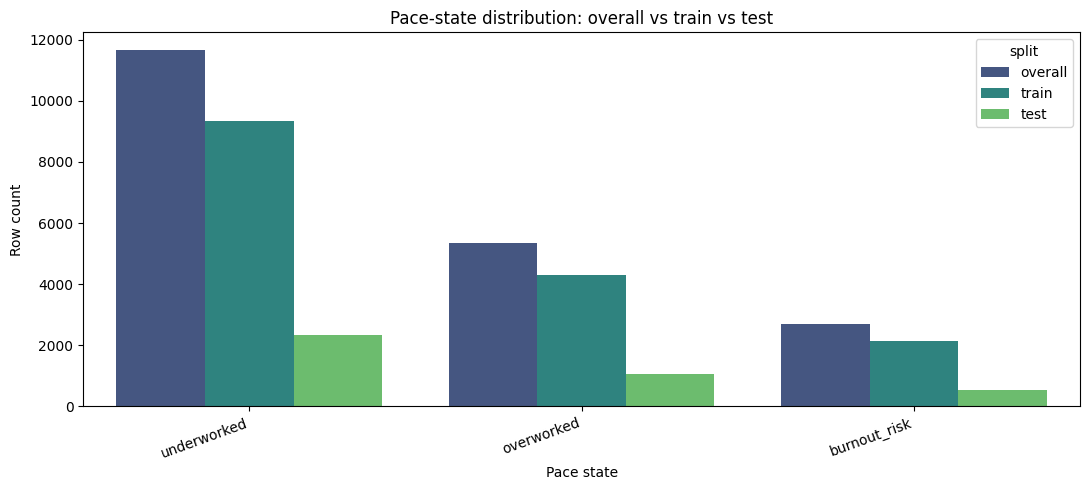

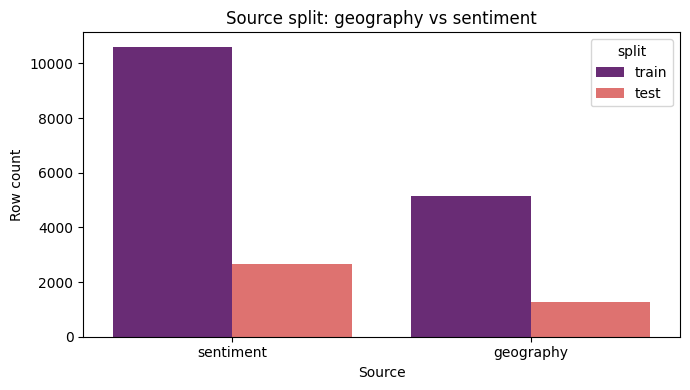

(              overall  train  test
 underworked     11659   9327  2332
 overworked       5359   4287  1072
 burnout_risk     2685   2148   537,
            train  test
 sentiment  10610  2673
 geography   5152  1268)

In [61]:
plot_df = class_split_df.reset_index().rename(columns={"index": "label"})
long_df = plot_df.melt(id_vars=["label"], value_vars=["overall", "train", "test"], var_name="split", value_name="count")

plt.figure(figsize=(11, 5))
sns.barplot(data=long_df, x="label", y="count", hue="split", palette="viridis")
plt.title("Pace-state distribution: overall vs train vs test")
plt.xlabel("Pace state")
plt.ylabel("Row count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

src_plot = source_split_df.reset_index().rename(columns={"index": "source"})
src_long = src_plot.melt(id_vars=["source"], value_vars=["train", "test"], var_name="split", value_name="count")

plt.figure(figsize=(7, 4))
sns.barplot(data=src_long, x="source", y="count", hue="split", palette="magma")
plt.title("Source split: geography vs sentiment")
plt.xlabel("Source")
plt.ylabel("Row count")
plt.tight_layout()
plt.show()

class_split_df, source_split_df

## Quick sanity check (one row)

In [62]:
base_df = X if isinstance(X, pd.DataFrame) and len(X) > 0 else geo_df
source = base_df.iloc[0].to_dict()
example = {c: source.get(c, None) for c in bundle["feature_columns"]}

row = pd.DataFrame([example])
code = int(pipe.predict(row)[0])
label = le.inverse_transform([code])[0] if le is not None else code
print("prediction:", label)
print("features used:", list(example.keys()))

prediction: underworked
features used: ['Entity', 'Code', 'Year', 'statement_len', 'word_count', 'exclamation_count', 'question_count', 'neg_word_hits', 'risk_word_hits']


## Serve ML over HTTP (for backend integration)

Use the same ML service port for request + response flow.

Backend should POST JSON to either:
- `/predict`
- `/backend/predict` (alias for backend use)

Request body format:

```json
{
  "features": {
    "Entity": "NEPAL",
    "Code": "NEP",
    "Year": 2021,
    "statement_len": 90,
    "word_count": 18,
    "exclamation_count": 0,
    "question_count": 1,
    "neg_word_hits": 2,
    "risk_word_hits": 0
  }
}
```

In [66]:
import os
import subprocess
import sys
import time
import urllib.request

host = os.environ.get("ML_HOST", "127.0.0.1")
port = int(os.environ.get("ML_PORT", "8000"))
health_url = f"http://{host}:{port}/health"


def _is_healthy(url: str) -> bool:
    try:
        with urllib.request.urlopen(url, timeout=1) as resp:
            return resp.status == 200
    except Exception:
        return False


if _is_healthy(health_url):
    print(f"ML API already reachable at http://{host}:{port}")
elif "ML_API_PROCESS" in globals() and ML_API_PROCESS is not None and ML_API_PROCESS.poll() is None:
    print(f"ML API process already running (pid={ML_API_PROCESS.pid}), waiting for health...")
else:
    cmd = [
        sys.executable,
        "-m",
        "uvicorn",
        "mental_health_ml.serve:app",
        "--host",
        host,
        "--port",
        str(port),
    ]
    ML_API_PROCESS = subprocess.Popen(cmd)

for _ in range(30):
    if _is_healthy(health_url):
        print(f"ML API ready on http://{host}:{port}")
        print("Use endpoint: POST /predict or POST /backend/predict")
        break
    time.sleep(0.2)
else:
    print(f"ML API did not become healthy on {health_url}. Check if the port is already in use.")

ML API already reachable at http://127.0.0.1:8000
ML API ready on http://127.0.0.1:8000
Use endpoint: POST /predict or POST /backend/predict


In [65]:
import signal

if "ML_API_PROCESS" in globals() and ML_API_PROCESS is not None and ML_API_PROCESS.poll() is None:
    ML_API_PROCESS.terminate()
    try:
        ML_API_PROCESS.wait(timeout=5)
    except Exception:
        ML_API_PROCESS.kill()
    print("ML API stopped")
else:
    print("No notebook-started ML API process is running")

No notebook-started ML API process is running
